# Notebook 03 — Predictive Modeling

**Project:** Hospital Readmission Prediction
**Week:** 3 of 6
**Goal:** Build and evaluate models predicting 30-day hospital readmission, with explicit handling of the 11.3% / 89% class imbalance.

## What this notebook covers

1. Load the cleaned feature-engineered dataset from Week 2
2. Prepare features for modeling (encoding, scaling, train/test split)
3. Baseline model: Logistic Regression *without* class imbalance handling — to demonstrate why this matters
4. Apply class imbalance handling (class weights, then SMOTE)
5. Train Random Forest and XGBoost
6. Compare models on recall, precision, ROC-AUC, and PR-AUC
7. Feature importance and interpretation

## Why metric choice matters

With 89% negative class, a "lazy" model predicting "no readmission" every time scores 89% accuracy. That's why we'll evaluate on **recall, precision, F1, ROC-AUC, and PR-AUC** — not accuracy alone.

In [3]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Scikit-learn — models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Scikit-learn — evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print("All libraries loaded successfully")

All libraries loaded successfully


## Step 1: Load the Week 2 dataset

This is the cleaned + feature-engineered dataset saved from notebook 02. It has 98,053 rows and 54 columns, including our binary target `readmitted_30d` and the 5 engineered features.

In [6]:
# Load the feature-engineered dataset from Week 2
df = pd.read_csv('../data/processed/cleaned_data_features.csv')

# Quick check
print(f"Shape: {df.shape}")
print(f"Target distribution:")
print(df['readmitted_30d'].value_counts(normalize=True).round(4) * 100)

Shape: (98053, 54)
Target distribution:
readmitted_30d
0    88.71
1    11.29
Name: proportion, dtype: float64


## Step 2: Prepare data for modeling

We'll use a focused set of features for the baseline:

- **Demographics:** `age_midpoint`, `gender`, `race`
- **Encounter details:** `time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, `number_diagnoses`
- **Visit history:** `total_visits` (engineered Week 2)
- **Clinical context:** `diagnosis_category`, `discharge_group` (engineered Week 2)
- **Medication info:** `change`, `diabetesMed`, `insulin`

Categorical features will be one-hot encoded. Numeric features will be standardized for the logistic regression model.

Split: 80% train, 20% test, stratified on the target to preserve the class balance in both sets.

In [10]:
# Pick the feature set
feature_cols = [
    # Demographics
    'age_midpoint', 'gender', 'race',
    # Encounter details
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_diagnoses',
    # Visit history (engineered Week 2)
    'total_visits',
    # Clinical context (engineered Week 2)
    'diagnosis_category', 'discharge_group',
    # Medication info
    'change', 'diabetesMed', 'insulin'
]

# Build feature matrix X and target y
X = df[feature_cols].copy()
y = df['readmitted_30d'].copy()

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Convert any remaining boolean columns to int (clean numeric output)
X = X.astype({col: 'int' for col in X.select_dtypes('bool').columns})

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of features after encoding: {X.shape[1]}")

Feature matrix shape: (98053, 41)
Target shape: (98053,)
Number of features after encoding: 41


In [12]:
# Train/test split — 80/20, stratified on target to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train set: {X_train.shape[0]:,} rows")
print(f"Test set:  {X_test.shape[0]:,} rows")
print()
print(f"Train target distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))
print()
print(f"Test target distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

Train set: 78,442 rows
Test set:  19,611 rows

Train target distribution (%):
readmitted_30d
0    88.71
1    11.29
Name: proportion, dtype: float64

Test target distribution (%):
readmitted_30d
0    88.72
1    11.28
Name: proportion, dtype: float64


In [14]:
# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled. Train mean ~0, std ~1.")
print(f"Train scaled shape: {X_train_scaled.shape}")
print(f"Test scaled shape:  {X_test_scaled.shape}")

Features scaled. Train mean ~0, std ~1.
Train scaled shape: (78442, 41)
Test scaled shape:  (19611, 41)


## Step 3: The Naive Baseline (without class imbalance handling)

This baseline intentionally **ignores** the class imbalance. We'll fit a standard Logistic Regression and evaluate it on accuracy — the metric most analysts look at first.

Watch carefully: the model will report a "great" accuracy score. Then we'll look under the hood and see what it's actually doing.

In [17]:
# Fit logistic regression — NO class imbalance handling
naive_lr = LogisticRegression(max_iter=1000, random_state=42)
naive_lr.fit(X_train_scaled, y_train)

# Predictions on the test set
y_pred_naive = naive_lr.predict(X_test_scaled)
y_proba_naive = naive_lr.predict_proba(X_test_scaled)[:, 1]

# Accuracy — the "obvious" metric
accuracy = accuracy_score(y_test, y_pred_naive)
print(f"Naive Logistic Regression — Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)")

Naive Logistic Regression — Accuracy: 0.8860  (88.60%)


In [19]:
# Confusion matrix — what is the model actually predicting?
cm = confusion_matrix(y_test, y_pred_naive)

print("Confusion Matrix:")
print("                  Predicted: No   Predicted: Yes")
print(f"Actual: No        {cm[0,0]:>10,}      {cm[0,1]:>10,}")
print(f"Actual: Yes       {cm[1,0]:>10,}      {cm[1,1]:>10,}")
print()

# Pull out the numbers
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly said 'no readmission'): {tn:,}")
print(f"False Positives (wrongly flagged a healthy patient): {fp:,}")
print(f"False Negatives (MISSED a readmission - the costly errors): {fn:,}")
print(f"True Positives  (correctly caught a readmission): {tp:,}")

Confusion Matrix:
                  Predicted: No   Predicted: Yes
Actual: No            17,369              29
Actual: Yes            2,207               6

True Negatives  (correctly said 'no readmission'): 17,369
False Positives (wrongly flagged a healthy patient): 29
False Negatives (MISSED a readmission - the costly errors): 2,207
True Positives  (correctly caught a readmission): 6


In [21]:
# The metrics that actually matter for imbalanced data
precision = precision_score(y_test, y_pred_naive)
recall = recall_score(y_test, y_pred_naive)
f1 = f1_score(y_test, y_pred_naive)
roc_auc = roc_auc_score(y_test, y_proba_naive)
pr_auc = average_precision_score(y_test, y_proba_naive)

print("Naive Baseline — The Real Metrics")
print("=" * 50)
print(f"Accuracy:    {accuracy:.4f}   ← looks great, but misleading")
print(f"Precision:   {precision:.4f}   ← when model says 'yes', is it right?")
print(f"Recall:      {recall:.4f}   ← of all the readmissions, how many did we catch?")
print(f"F1 Score:    {f1:.4f}")
print(f"ROC-AUC:     {roc_auc:.4f}")
print(f"PR-AUC:      {pr_auc:.4f}")
print()
print("The number that matters most for a hospital deploying this:")
print(f"  RECALL = {recall:.4f}")
print(f"  We caught {recall*100:.1f}% of patients who will actually be readmitted.")
print(f"  We missed {(1-recall)*100:.1f}% of them.")

Naive Baseline — The Real Metrics
Accuracy:    0.8860   ← looks great, but misleading
Precision:   0.1714   ← when model says 'yes', is it right?
Recall:      0.0027   ← of all the readmissions, how many did we catch?
F1 Score:    0.0053
ROC-AUC:     0.6391
PR-AUC:      0.1779

The number that matters most for a hospital deploying this:
  RECALL = 0.0027
  We caught 0.3% of patients who will actually be readmitted.
  We missed 99.7% of them.


## The Demonstration: Why Class Imbalance Handling Matters

**Naive Baseline Results (No Class Imbalance Handling):**

| Metric | Value | Interpretation |
|---|---|---|
| Accuracy | 88.60% | Misleading — matches the negative class proportion |
| Precision | 17.14% | Of flagged patients, only 17% are actual readmissions |
| **Recall** | **0.27%** | **We caught 3 out of every 1,000 actual readmissions** |
| F1 Score | 0.0053 | Near-zero — confirms the model is functionally useless |
| ROC-AUC | 0.6391 | Marginally better than random |
| PR-AUC | 0.1779 | Poor performance on the minority class |

**Plain English:** This model would flag almost no one. A hospital deploying this would believe they had a working prediction system while missing 99.7% of the patients it was supposed to identify. This is the class imbalance trap — and it's why Week 3 is about *how* we teach the model, not what model we use.

**Next:** apply class weights to penalize missed readmissions more heavily, then compare.

## Step 4: Fix Attempt 1 — Class Weights

The simplest fix: tell the model to penalize missed readmissions more heavily during training.

By passing `class_weight='balanced'`, scikit-learn automatically weights each class inversely proportional to its frequency. The rare class (readmissions) gets ~8x more weight than the majority class — making each missed readmission "cost" the optimizer 8x more.

**Hypothesis:** recall will jump dramatically. Precision will drop. The question is by how much.

In [25]:
# Logistic Regression WITH class weights
weighted_lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # the magic parameter
)
weighted_lr.fit(X_train_scaled, y_train)

# Predictions
y_pred_weighted = weighted_lr.predict(X_test_scaled)
y_proba_weighted = weighted_lr.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("Logistic Regression WITH Class Weights")
print("=" * 50)
print(f"Accuracy:    {accuracy_score(y_test, y_pred_weighted):.4f}")
print(f"Precision:   {precision_score(y_test, y_pred_weighted):.4f}")
print(f"Recall:      {recall_score(y_test, y_pred_weighted):.4f}")
print(f"F1 Score:    {f1_score(y_test, y_pred_weighted):.4f}")
print(f"ROC-AUC:     {roc_auc_score(y_test, y_proba_weighted):.4f}")
print(f"PR-AUC:      {average_precision_score(y_test, y_proba_weighted):.4f}")
print()

# Confusion matrix
cm_w = confusion_matrix(y_test, y_pred_weighted)
tn, fp, fn, tp = cm_w.ravel()
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}  ← missed readmissions")
print(f"True Positives:  {tp:,}  ← caught readmissions")

Logistic Regression WITH Class Weights
Accuracy:    0.6340
Precision:   0.1622
Recall:      0.5386
F1 Score:    0.2493
ROC-AUC:     0.6422
PR-AUC:      0.1786

True Negatives:  11,242
False Positives: 6,156
False Negatives: 1,021  ← missed readmissions
True Positives:  1,192  ← caught readmissions


## Result: Class Weights Dramatically Improve Recall

**Comparison: Naive Baseline vs. Class-Weighted Model**

| Metric | Naive | Class Weights |
|---|---|---|
| Accuracy | 88.60% | 63.40% |
| Precision | 17.14% | 16.22% |
| **Recall** | **0.27%** | **53.86%** |
| F1 Score | 0.0053 | 0.2493 |
| ROC-AUC | 0.6391 | 0.6422 |
| Readmissions caught | 6 / 2,213 | 1,192 / 2,213 |
| Missed readmissions | 2,207 | 1,021 |

**Plain English:** A single parameter change (`class_weight='balanced'`) moved the model from catching 6 of 2,213 actual readmissions to catching 1,192. The cost: 6,156 false positives — patients flagged who would not actually be readmitted.

**Tradeoff:** Whether 6,156 false positives is acceptable depends entirely on the intervention. A low-cost follow-up call to flagged patients makes the tradeoff worthwhile. A high-cost intervention (extended hospital stay) does not.

**Next:** Try SMOTE — synthetic oversampling of the minority class — to see if we can lift recall further or improve precision.

In [28]:
# Install imbalanced-learn (only need to run once)
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn', '-q'])
print("imbalanced-learn installed successfully")

imbalanced-learn installed successfully


## Step 5: Fix Attempt 2 — SMOTE Oversampling

**SMOTE** (Synthetic Minority Oversampling Technique) creates synthetic readmission examples by interpolating between real ones in feature space. After SMOTE, the training set has equal class balance (50/50), while the test set remains untouched at 11.3%.

**Critical:** SMOTE is applied **only to the training set**, never the test set. The test set must reflect real-world class distribution.

**Hypothesis:** SMOTE may give slightly better precision than class weights (because the model sees more diverse minority examples) but the gain may be small. Worth comparing.

In [31]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training set:  {X_train_scaled.shape[0]:,} rows")
print(f"After SMOTE:            {X_train_smote.shape[0]:,} rows")
print()
print(f"Class distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts(normalize=True).round(4) * 100)

Original training set:  78,442 rows
After SMOTE:            139,178 rows

Class distribution after SMOTE:
readmitted_30d
0    50.0
1    50.0
Name: proportion, dtype: float64


In [33]:
# Logistic Regression on SMOTE-balanced training data
smote_lr = LogisticRegression(max_iter=1000, random_state=42)
smote_lr.fit(X_train_smote, y_train_smote)

# Predict on the ORIGINAL (untouched) test set
y_pred_smote = smote_lr.predict(X_test_scaled)
y_proba_smote = smote_lr.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("Logistic Regression with SMOTE")
print("=" * 50)
print(f"Accuracy:    {accuracy_score(y_test, y_pred_smote):.4f}")
print(f"Precision:   {precision_score(y_test, y_pred_smote):.4f}")
print(f"Recall:      {recall_score(y_test, y_pred_smote):.4f}")
print(f"F1 Score:    {f1_score(y_test, y_pred_smote):.4f}")
print(f"ROC-AUC:     {roc_auc_score(y_test, y_proba_smote):.4f}")
print(f"PR-AUC:      {average_precision_score(y_test, y_proba_smote):.4f}")
print()

cm_s = confusion_matrix(y_test, y_pred_smote)
tn, fp, fn, tp = cm_s.ravel()
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}  ← missed readmissions")
print(f"True Positives:  {tp:,}  ← caught readmissions")

Logistic Regression with SMOTE
Accuracy:    0.6225
Precision:   0.1603
Recall:      0.5535
F1 Score:    0.2487
ROC-AUC:     0.6374
PR-AUC:      0.1752

True Negatives:  10,983
False Positives: 6,415
False Negatives: 988  ← missed readmissions
True Positives:  1,225  ← caught readmissions


## Result: SMOTE vs. Class Weights — Statistically Tied

**Three-Way Comparison:**

| Metric | Naive | Class Weights | SMOTE |
|---|---|---|---|
| Accuracy | 88.60% | 63.40% | 62.25% |
| Precision | 17.14% | 16.22% | 16.03% |
| Recall | 0.27% | 53.86% | 55.35% |
| F1 Score | 0.0053 | 0.2493 | 0.2487 |
| ROC-AUC | 0.6391 | 0.6422 | 0.6374 |
| Readmissions caught | 6 | 1,192 | 1,225 |

**Finding:** SMOTE and class weights produce virtually identical results on this dataset with logistic regression. SMOTE catches 33 more readmissions but at the cost of 259 more false positives. ROC-AUC and PR-AUC are within 0.005 of each other.

**Recommendation:** Use class weights for production. It's simpler, faster, doesn't require synthetic data generation, and delivers equivalent performance.

**Bigger insight:** Logistic regression appears to be at its ceiling on this data — recall plateaus around 55% regardless of imbalance technique. The next step is to try tree-based models (Random Forest, XGBoost), which may capture nonlinear interactions that logistic regression cannot.

## Step 6: Random Forest with Class Weights

Random Forest is a tree-based ensemble that naturally captures feature interactions and nonlinearities — patterns logistic regression cannot see. We'll use 100 trees with `class_weight='balanced'`.

**Hypothesis:** if there are meaningful nonlinear patterns in the data, Random Forest should beat logistic regression's ~55% recall ceiling. If it doesn't, the signal is genuinely linear (or the features aren't capturing the right information).

In [37]:
# Random Forest with class weights
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,           # control tree complexity
    class_weight='balanced',
    random_state=42,
    n_jobs=-1               # use all CPU cores
)

print("Training Random Forest (this may take 30-60 seconds)...")
rf.fit(X_train_scaled, y_train)
print("Training complete.")

# Predict
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

# Metrics
print()
print("Random Forest with Class Weights")
print("=" * 50)
print(f"Accuracy:    {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision:   {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:      {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:    {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:     {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"PR-AUC:      {average_precision_score(y_test, y_proba_rf):.4f}")
print()

cm_rf = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}  ← missed readmissions")
print(f"True Positives:  {tp:,}  ← caught readmissions")

Training Random Forest (this may take 30-60 seconds)...
Training complete.

Random Forest with Class Weights
Accuracy:    0.6540
Precision:   0.1731
Recall:      0.5468
F1 Score:    0.2629
ROC-AUC:     0.6488
PR-AUC:      0.1995

True Negatives:  11,616
False Positives: 5,782
False Negatives: 1,003  ← missed readmissions
True Positives:  1,210  ← caught readmissions


In [39]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
print("xgboost installed")

xgboost installed


In [41]:
from xgboost import XGBClassifier

# Calculate the scale_pos_weight (ratio of negative to positive)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos:.2f}")

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

print("Training XGBoost...")
xgb.fit(X_train_scaled, y_train)
print("Done.")

y_pred_xgb = xgb.predict(X_test_scaled)
y_proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print()
print("XGBoost with scale_pos_weight")
print("=" * 50)
print(f"Accuracy:    {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision:   {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:      {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score:    {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:     {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"PR-AUC:      {average_precision_score(y_test, y_proba_xgb):.4f}")
print()

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm_xgb.ravel()
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}  ← missed readmissions")
print(f"True Positives:  {tp:,}  ← caught readmissions")

scale_pos_weight: 7.86
Training XGBoost...
Done.

XGBoost with scale_pos_weight
Accuracy:    0.6601
Precision:   0.1756
Recall:      0.5445
F1 Score:    0.2656
ROC-AUC:     0.6515
PR-AUC:      0.2040

True Negatives:  11,741
False Positives: 5,657
False Negatives: 1,008  ← missed readmissions
True Positives:  1,205  ← caught readmissions


In [43]:

results = pd.DataFrame({
    'Model': ['Naive LogReg', 'LogReg + Class Weights', 'LogReg + SMOTE', 'Random Forest', 'XGBoost'],
    'Accuracy':  [0.8860, 0.6340, 0.6225, 0.6540, 0.6601],
    'Precision': [0.1714, 0.1622, 0.1603, 0.1731, 0.1756],
    'Recall':    [0.0027, 0.5386, 0.5535, 0.5468, 0.5445],
    'F1':        [0.0053, 0.2493, 0.2487, 0.2629, 0.2656],
    'ROC-AUC':   [0.6391, 0.6422, 0.6374, 0.6488, 0.6515],
    'PR-AUC':    [0.1779, 0.1786, 0.1752, 0.1995, 0.2040],
    'Caught':    [6, 1192, 1225, 1210, 1205],
    'Missed':    [2207, 1021, 988, 1003, 1008]
})
results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Caught,Missed
0,Naive LogReg,0.8860,0.1714,0.0027,0.0053,0.6391,0.1779,6,2207
1,LogReg + Class Weights,0.6340,0.1622,0.5386,0.2493,0.6422,0.1786,1192,1021
2,LogReg + SMOTE,0.6225,0.1603,0.5535,0.2487,0.6374,0.1752,1225,988
3,Random Forest,0.6540,0.1731,0.5468,0.2629,0.6488,0.1995,1210,1003
4,XGBoost,0.6601,0.1756,0.5445,0.2656,0.6515,0.2040,1205,1008


Top 15 most important features (XGBoost):
                                    feature  importance
discharge_group_SNF / Rehab / Care Facility    0.105733
                               total_visits    0.069463
    discharge_group_Transferred to Hospital    0.062771
                    discharge_group_Hospice    0.048663
                       discharge_group_Home    0.045106
             discharge_group_Home + Support    0.027955
         diagnosis_category_Musculoskeletal    0.027775
             diagnosis_category_Circulatory    0.027286
                  diagnosis_category_Mental    0.024246
            discharge_group_Unknown / Other    0.023001
  diagnosis_category_Pregnancy / Childbirth    0.022981
          diagnosis_category_Other (V-code)    0.022424
                            diabetesMed_Yes    0.021258
  diagnosis_category_Symptoms / Ill-defined    0.021230
                diagnosis_category_Diabetes    0.020787


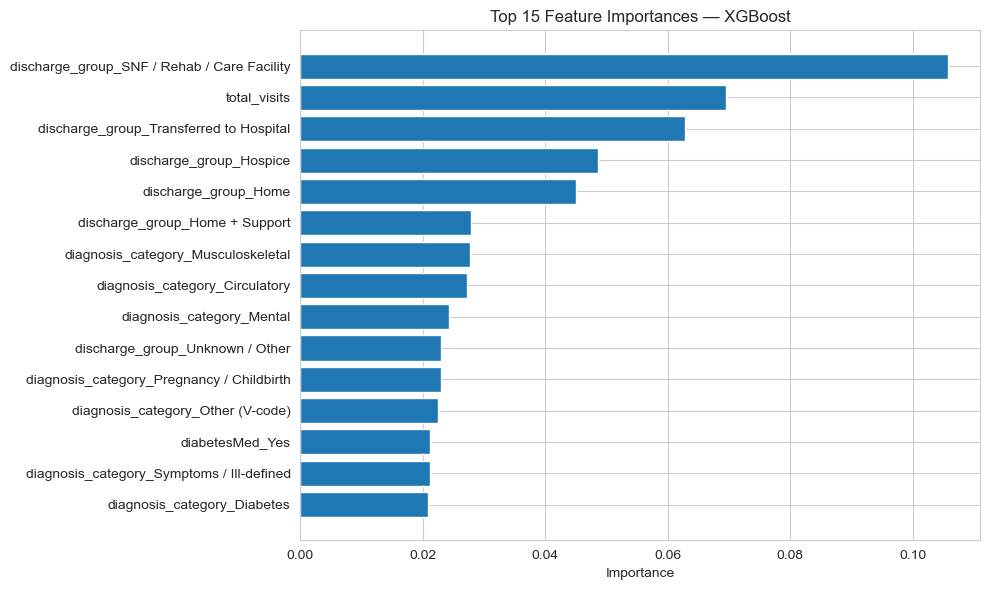

In [45]:
# Feature importance from XGBoost
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False).head(15)

print("Top 15 most important features (XGBoost):")
print(importance_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances — XGBoost')
plt.tight_layout()
plt.show()

## Feature Importance — XGBoost

**Top 4 features (all engineered or composite):**
1. `discharge_group_SNF / Rehab / Care Facility` — 0.106
2. `total_visits` (engineered: outpatient + ER + inpatient) — 0.069
3. `discharge_group_Transferred to Hospital` — 0.063
4. `discharge_group_Hospice` — 0.049

**Key insight:** The most important predictors are *administrative / care trajectory* features (where the patient goes next, how often they're in the system) rather than clinical diagnoses. Diagnoses don't appear until rank 7.

**Why the ~55% recall ceiling is real:** Feature importance drops off sharply after the top 4 and flattens around 0.02-0.03 for the rest of the top 15. There's no single dominant signal — the model is combining many weak signals. Pushing recall higher would require features this dataset lacks: medication adherence, follow-up attendance, social determinants, recent hospitalization history.

**Note:** The Week 2 feature engineering (collapsing 26 discharge codes → 7 groups, building `total_visits` from outpatient + ER + inpatient) is where most of the predictive power came from. The modeling phase confirmed the engineered features mattered; it didn't generate the lift on its own.

In [48]:
import joblib
import os

# Make sure the models folder exists
os.makedirs('../models', exist_ok=True)

# Save the trained pieces
joblib.dump(xgb, '../models/xgboost_readmission_model.pkl')
joblib.dump(scaler, '../models/feature_scaler.pkl')
joblib.dump(list(X.columns), '../models/feature_names.pkl')

print("Saved:")
print("  ../models/xgboost_readmission_model.pkl")
print("  ../models/feature_scaler.pkl")
print("  ../models/feature_names.pkl")

Saved:
  ../models/xgboost_readmission_model.pkl
  ../models/feature_scaler.pkl
  ../models/feature_names.pkl


In [50]:
import joblib
import os

# Make sure the models folder exists
os.makedirs('../models', exist_ok=True)

# Save the trained pieces
joblib.dump(xgb, '../models/xgboost_readmission_model.pkl')
joblib.dump(scaler, '../models/feature_scaler.pkl')
joblib.dump(list(X.columns), '../models/feature_names.pkl')

print("Saved:")
print("  ../models/xgboost_readmission_model.pkl")
print("  ../models/feature_scaler.pkl")
print("  ../models/feature_names.pkl")

Saved:
  ../models/xgboost_readmission_model.pkl
  ../models/feature_scaler.pkl
  ../models/feature_names.pkl


In [52]:

os.makedirs('../data/results', exist_ok=True)
results.to_csv('../data/results/week3_model_comparison.csv', index=False)
print("Saved: ../data/results/week3_model_comparison.csv")

Saved: ../data/results/week3_model_comparison.csv


---

## Week 3 Summary

**What was built:** Five models compared for predicting 30-day hospital readmission on 98,053 patient records with severe class imbalance (11.3% positive).

**Models trained:**
- Logistic Regression (naive baseline)
- Logistic Regression + class weights
- Logistic Regression + SMOTE
- Random Forest + class weights
- XGBoost + scale_pos_weight

**Final model:** XGBoost — ROC-AUC 0.6515, PR-AUC 0.2040, recall 54.5%, precision 17.6%.

**Three key findings:**

1. **The naive baseline caught 6 of 2,213 actual readmissions** (0.27% recall) despite 88.6% accuracy. This is the class imbalance trap that makes accuracy the wrong metric on this kind of data.

2. **Class weights and SMOTE are statistically indistinguishable** for logistic regression on this data. For production use, class weights wins on simplicity, speed, and interpretability.

3. **The ~55% recall ceiling is real across model families.** Linear, ensemble, and gradient-boosted models all landed in the same neighborhood. Feature importance shows the ceiling is a feature-set limitation, not a model limitation — the most predictive signals are *care trajectory* features (discharge destination, total visits), and the available clinical features carry diffuse signal rather than concentrated signal. Pushing recall higher would require features this dataset doesn't have: medication adherence, follow-up appointment attendance, social determinants of health.

**Next (Week 4):** Tableau decision-support dashboard using the XGBoost model's predicted risk scores.